In [20]:
import liesel.model as lsl
import liesel.goose as gs

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

import jax.numpy as jnp
import jax
import numpy as np
import time
import datetime
import functools

In [21]:
# =============================================================================
#  1. DATA SIMULATION (Mixture of Normals)
# =============================================================================

def generate_mixture_simulated_data(n_units=300, n_obs=50, n_components=2, seed=42):
    np.random.seed(seed)

    n_alts   = 4
    n_params = 4   
    n_demos  = 2   

    Z = np.column_stack([np.ones(n_units), np.random.normal(0, 1, n_units)])
    pi_true = np.array([0.6, 0.4]) if n_components == 2 else np.ones(n_components) / n_components

    Delta_true = np.zeros((n_components, n_demos, n_params))
    Delta_true[0] = np.array([
        [ 2.5, -0.5, -0.5, -2.0],
        [ 0.8, -0.3,  0.0,  0.5],
    ])

    if n_components > 1:
        Delta_true[1] = np.array([
            [-1.5, -0.5,  2.5, -0.5],
            [-0.5,  0.2,  0.5, -0.1],
        ])

    Sigma_true = np.stack([np.diag([1.0, 0.5, 1.5, 0.5])] * n_components)

    beta_true = np.zeros((n_units, n_params))
    component_assignments = np.random.choice(n_components, size=n_units, p=pi_true)

    for i in range(n_units):
        k      = component_assignments[i]
        mu_i   = Z[i] @ Delta_true[k]
        beta_true[i] = np.random.multivariate_normal(mu_i, Sigma_true[k])

    X_list, y_list, unit_idx_list = [], [], []

    for i in range(n_units):
        for t in range(n_obs):
            X_it = np.zeros((n_alts, n_params))
            X_it[1, 0] = 1.0; X_it[2, 1] = 1.0; X_it[3, 2] = 1.0
            X_it[:, 3] = np.random.uniform(1.0, 5.0, n_alts)

            U_it  = X_it @ beta_true[i]
            probs = np.exp(U_it) / np.sum(np.exp(U_it))
            y_it  = np.random.choice(n_alts, p=probs)

            X_list.append(X_it)
            y_list.append(y_it)
            unit_idx_list.append(i)

    # CRITICAL FIX: Explicitly cast everything to float32 (or int32 for targets)
    return {
        "X":                  jnp.array(X_list, dtype=jnp.float32),
        "y":                  jnp.array(y_list, dtype=jnp.int32),
        "Z":                  jnp.array(Z, dtype=jnp.float32),
        "unit_idx":           jnp.array(unit_idx_list, dtype=jnp.int32),
        "n_units":            n_units,
        "n_params":           n_params,
        "n_alts":             n_alts,
        "n_z":                n_demos,
        "TRUE_DELTA":         Delta_true,
        "TRUE_SIGMA":         Sigma_true,
        "TRUE_BETA":          beta_true,
        "TRUE_COMPONENTS":    component_assignments,
        "TRUE_PI":            pi_true,
    }

In [22]:
# =============================================================================
#  2. DISTRIBUTION HELPERS
# =============================================================================

def make_wishart(df, scale_tril):
    return tfd.WishartTriL(
        df=df, scale_tril=scale_tril,
        input_output_cholesky=True, validate_args=False,
    )

def make_mixture(pvec, locs, precision_factors, n_units, K, n_params):
    prec_b = jnp.broadcast_to(
        precision_factors[None, ...], (n_units, K, n_params, n_params)
    )
    components = tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=locs,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(prec_b),
        validate_args=False,
    )
    mixture = tfd.Categorical(
        probs=jnp.broadcast_to(pvec, (n_units, K))
    )
    return tfd.MixtureSameFamily(
        mixture_distribution=mixture,
        components_distribution=components,
    )

In [23]:
# =============================================================================
#  3. MODEL BUILDING (Rossi-Consistent)
# =============================================================================

def build_rossi_mixture_hmnl(data_dict, K=2):
    n_params = int(data_dict["n_params"])
    n_units  = int(data_dict["n_units"])
    n_demos  = data_dict["Z"].shape[1]

    # CRITICAL FIX: Enforce jnp.float32 on all initial values and priors
    
    # -- 1. Mixing Weights (Dirichlet) --
    pvec = lsl.Var.new_param(
        value=jnp.ones(K, dtype=jnp.float32) / K,
        distribution=lsl.Dist(tfd.Dirichlet, concentration=jnp.ones(K, dtype=jnp.float32)),
        name="pvec"
    )
    pvec_latent = pvec.transform(tfb.SoftmaxCentered(), name="pvec_latent")

    # -- 2. Wishart prior for precision matrices --
    nu          = jnp.float32(n_params + 3)
    Vinv_chol   = jnp.linalg.cholesky(jnp.linalg.inv(nu * jnp.eye(n_params, dtype=jnp.float32)))
    batched_Vc  = jnp.stack([Vinv_chol] * K)

    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.stack([jnp.eye(n_params, dtype=jnp.float32)] * K),
        distribution=lsl.Dist(
            functools.partial(make_wishart, df=nu),
            scale_tril=batched_Vc,
        ),
        name="sigma_inv_chol",
    )
    
    sigma_inv_chol_latent = sigma_inv_chol.transform(
        tfb.FillScaleTriL(), name="sigma_inv_chol_latent"
    )

    # -- 3. Global demographic parameters (Delta) --
    Delta = lsl.Var.new_param(
        value=jnp.zeros((K, n_demos, n_params), dtype=jnp.float32),
        distribution=lsl.Dist(tfd.Normal, loc=jnp.float32(0.0), scale=jnp.float32(5.0)),
        name="Delta",
    )

    Z_var = lsl.Var.new_obs(data_dict["Z"], name="Z_obs")
    loc_var = lsl.Var.new_calc(
        lambda z, delta: jnp.einsum("ud,kdp->ukp", z, delta),
        z=Z_var, delta=Delta,
        name="beta_loc",
    )

    # -- 4. Individual-level parameters (Marginalized Mixture) --
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, n_params), dtype=jnp.float32),
        distribution=lsl.Dist(
            functools.partial(
                make_mixture, n_units=n_units, K=K, n_params=n_params
            ),
            pvec=pvec,
            locs=loc_var,
            precision_factors=sigma_inv_chol,
        ),
        name="beta_i",
    )

    # -- 5. Likelihood --
    X_var   = lsl.Var.new_obs(data_dict["X"],        name="X_obs")
    idx_var = lsl.Var.new_obs(data_dict["unit_idx"], name="idx_obs")

    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], b=beta_i, idx=idx_var, name="beta_expanded"
    )
    logits_var = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b),
        x=X_var, b=beta_expanded, name="logits",
    )
    y_var = lsl.Var.new_obs(
        data_dict["y"],
        distribution=lsl.Dist(tfd.Categorical, logits=logits_var),
        name="y",
    )

    return lsl.Model([y_var])

In [24]:
# =============================================================================
#  4. INFERENCE EXECUTION
# =============================================================================

def run_mixture_inference(model, chains=4, warmup=500, posterior=1000, seed=123):
    eb = gs.EngineBuilder(seed=seed, num_chains=chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    eb.add_kernel(gs.NUTSKernel(["pvec_latent"]))
    eb.add_kernel(gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False))
    eb.add_kernel(gs.NUTSKernel(["Delta"]))
    eb.add_kernel(gs.NUTSKernel(["beta_i"]))

    eb.set_duration(warmup_duration=warmup, posterior_duration=posterior)

    print("Starting NUTS sampling …")
    engine = eb.build()
    engine.sample_all_epochs()

    results = engine.get_results()
    return results, results.get_posterior_samples()

In [25]:
print("Simulating mixture data …")
K_COMPONENTS = 2
choice_data  = generate_mixture_simulated_data(n_components=K_COMPONENTS)

print(f"  Units : {choice_data['n_units']}")
print(f"  Obs   : {choice_data['y'].shape[0]}")
print(f"  K     : {K_COMPONENTS}")
print(f"  True π: {choice_data['TRUE_PI']}")

print("\nBuilding model …")
mix_model = build_rossi_mixture_hmnl(choice_data, K=K_COMPONENTS)

start_time = time.time()
mcmc_results, posterior_samples = run_mixture_inference(
    mix_model, chains=2, warmup=500, posterior=1000  
)

print(f"Sampling finished in {datetime.timedelta(seconds=int(time.time() - start_time))}")

Simulating mixture data …
  Units : 300
  Obs   : 15000
  K     : 2
  True π: [0.6 0.4]

Building model …


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting NUTS sampling …


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:27<00:00,  9.20s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1, 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 3, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1, 3 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_03: 2, 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 508.71chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 3, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1, 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain f

Sampling finished in 0:03:49


Standardizing array shapes for mixture comparison...

=== Mixing Weights (pvec) Recovery & Traces ===


,True_Prob,Posterior_Mean,Std_Dev
Component,,,
K=0,0.6,0.603523,0.028159
K=1,0.4,0.396477,0.028159


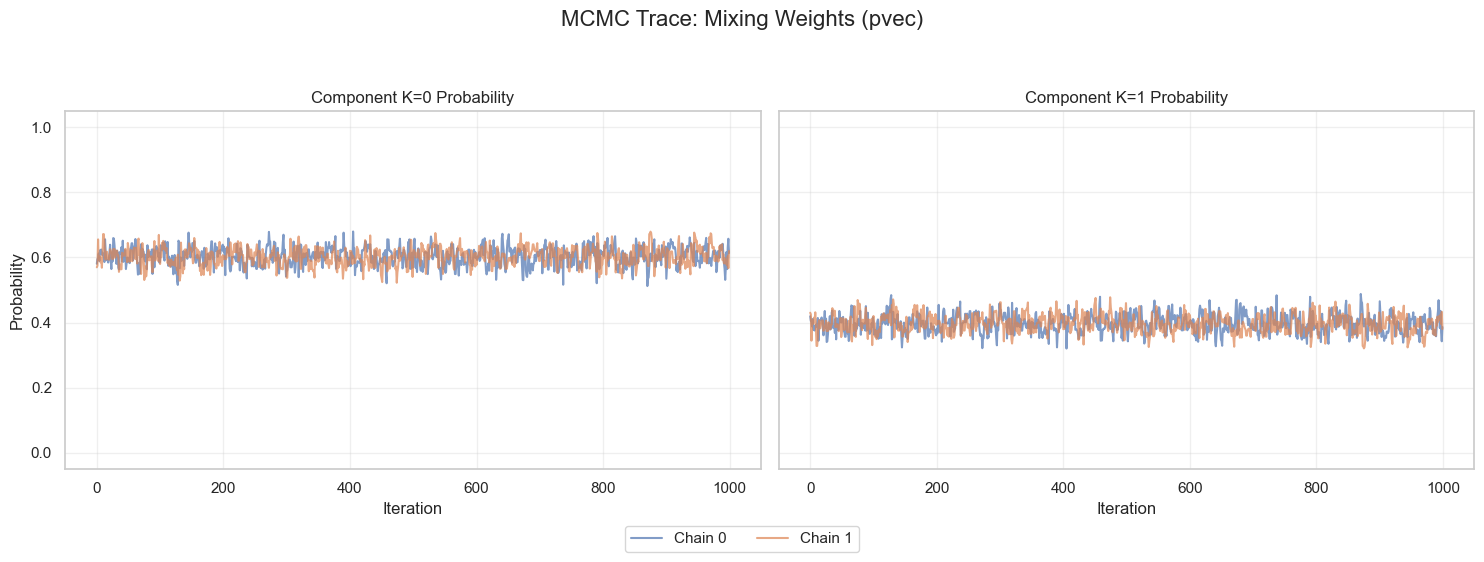


=== Global Parameters (Delta) ===

--- Delta Parameters: Component 0 ---


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),2.5,-0.5,-0.5,-2.0
Demographic 1,0.8,-0.3,0.0,0.5


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),2.62 (0.10),-0.40 (0.08),-0.42 (0.11),-1.98 (0.07)
Demographic 1,0.82 (0.10),-0.19 (0.09),-0.02 (0.11),0.47 (0.06)


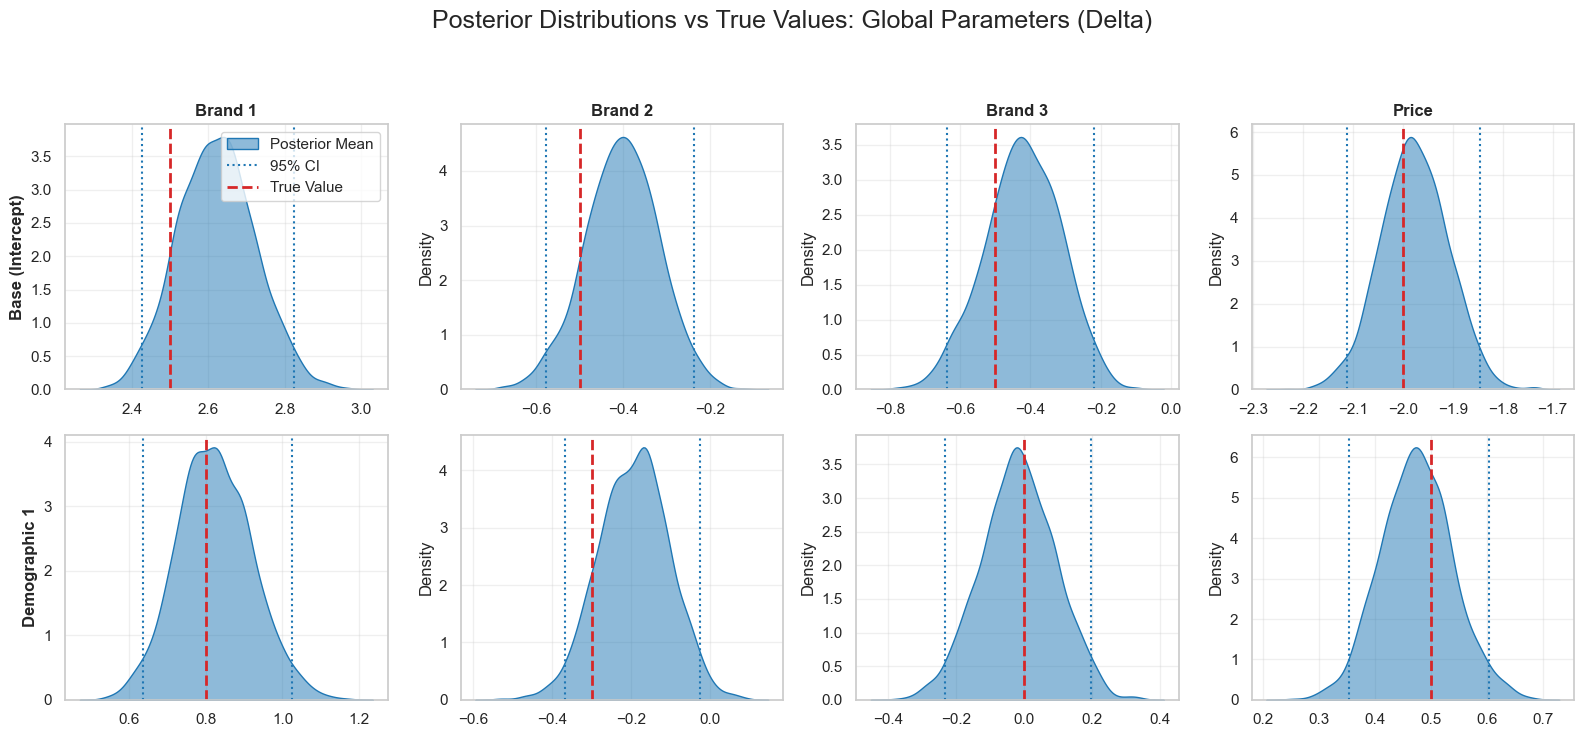


--- Delta Parameters: Component 1 ---


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),-1.5,-0.5,2.5,-0.5
Demographic 1,-0.5,0.2,0.5,-0.1


,Brand 1,Brand 2,Brand 3,Price
Base (Intercept),-1.34 (0.16),-0.52 (0.14),2.70 (0.13),-0.37 (0.07)
Demographic 1,-0.35 (0.16),0.36 (0.15),0.55 (0.15),-0.06 (0.08)


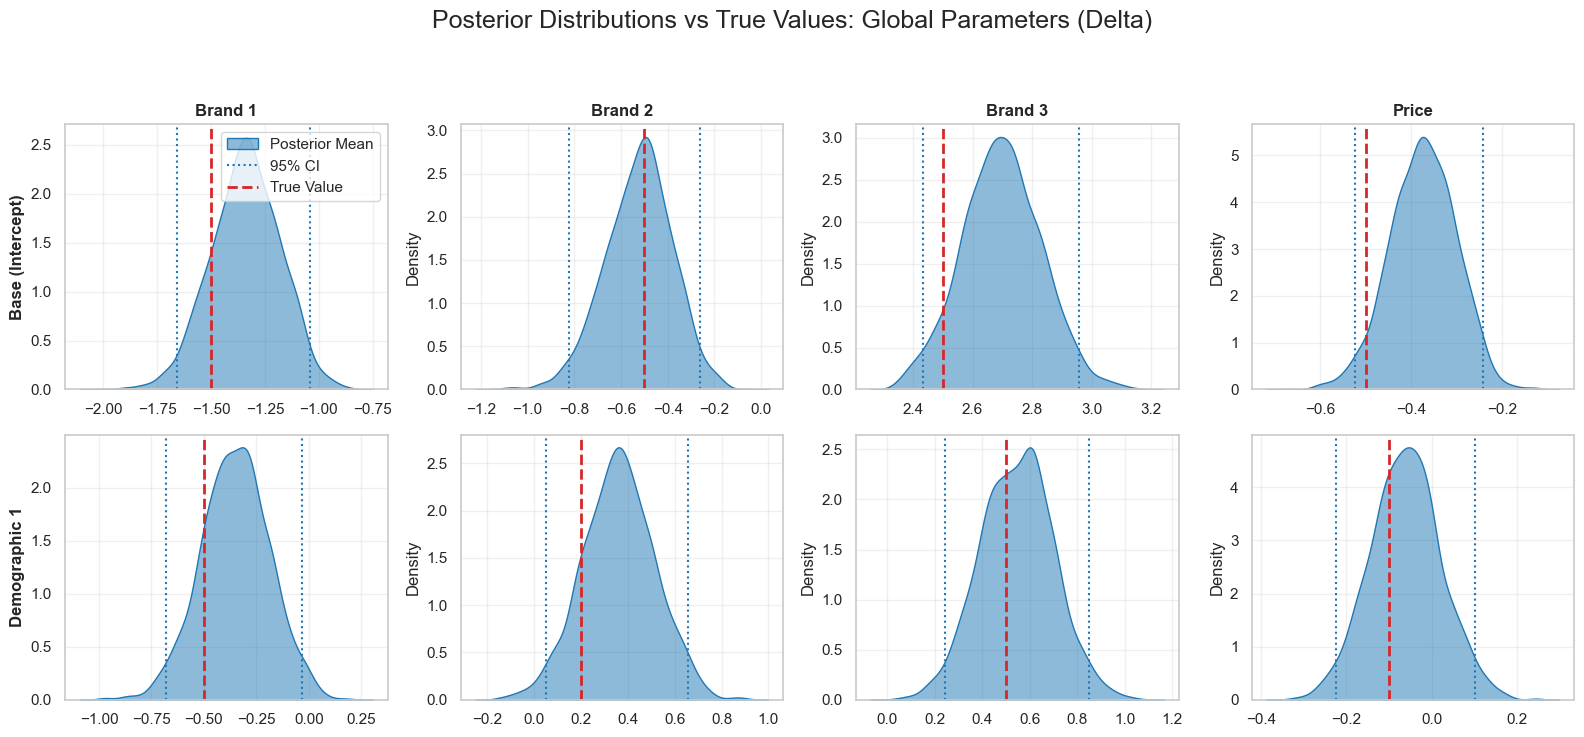


=== Recovering Covariance Matrices (Sigma) & Traces ===


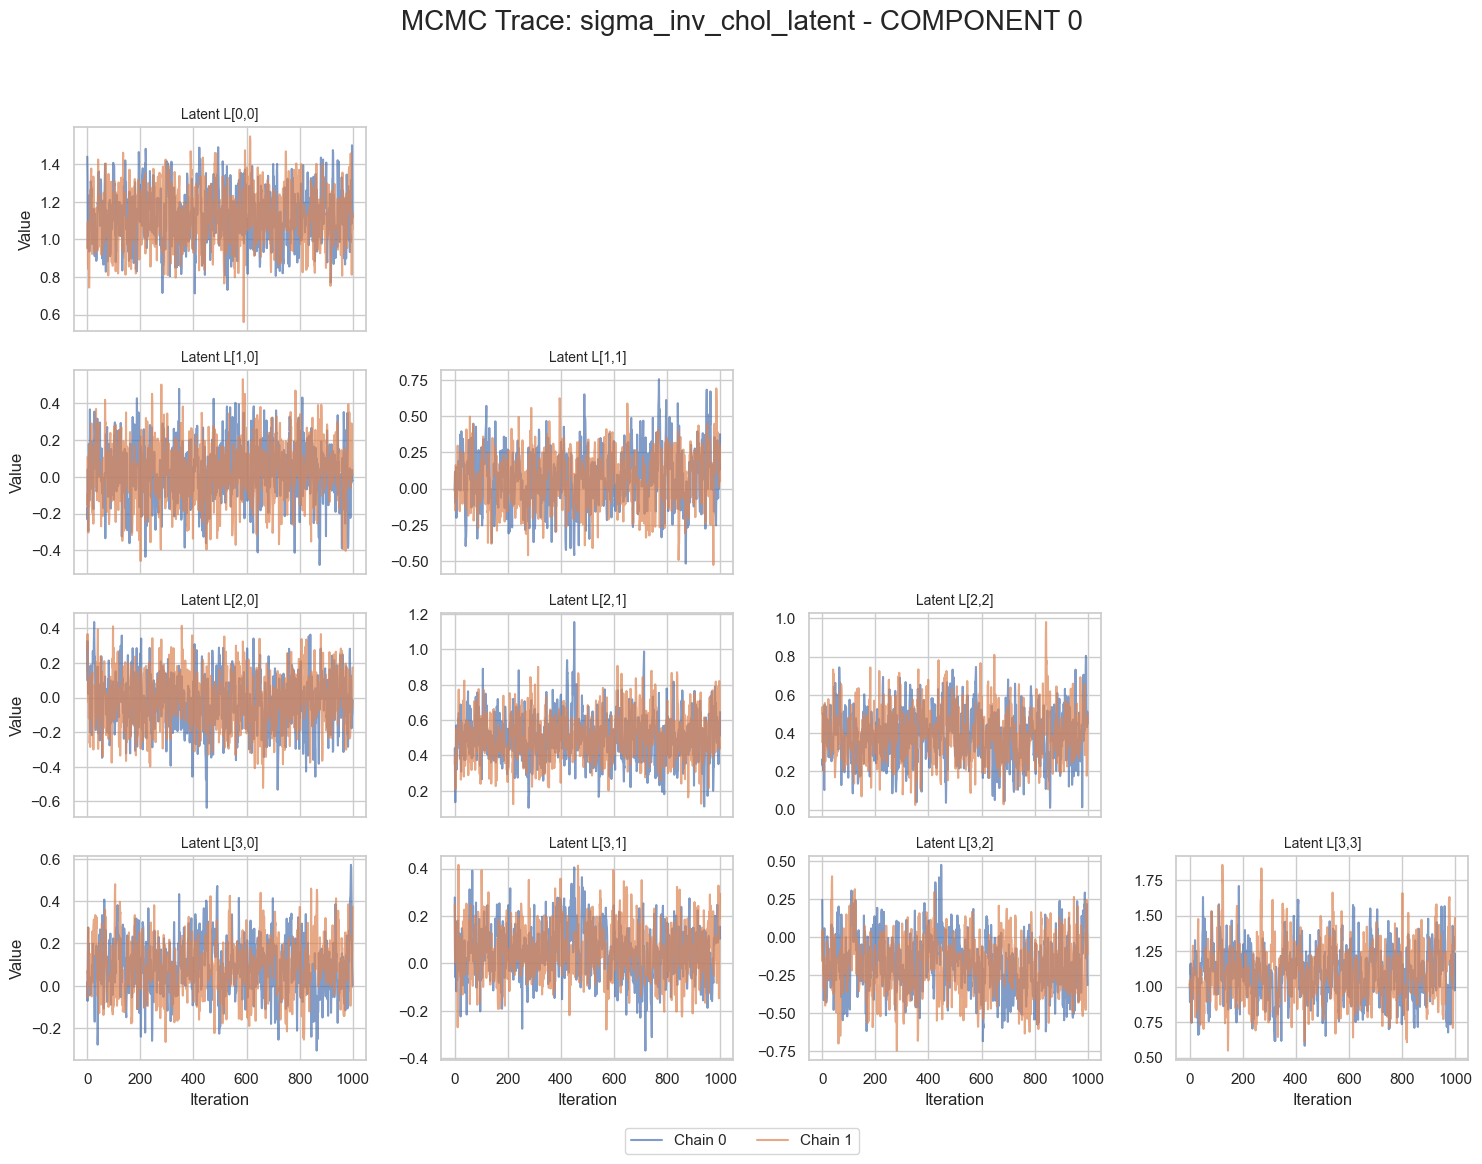

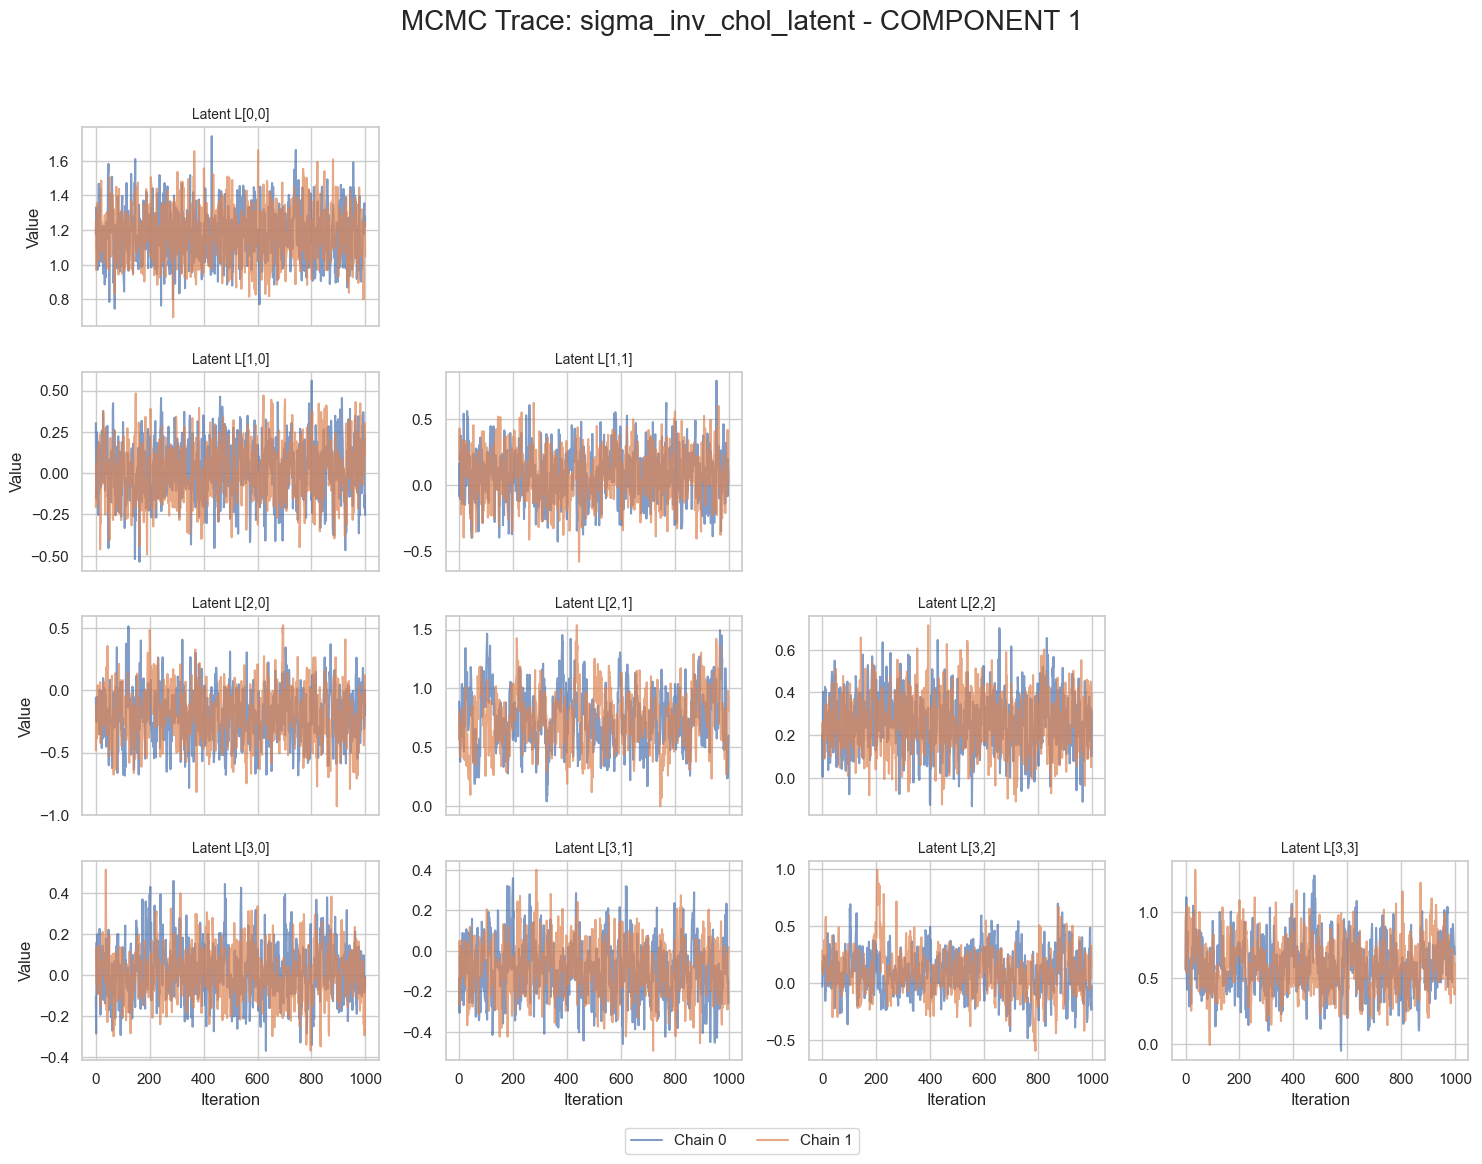


--- Plotting Covariance for Component 0 ---


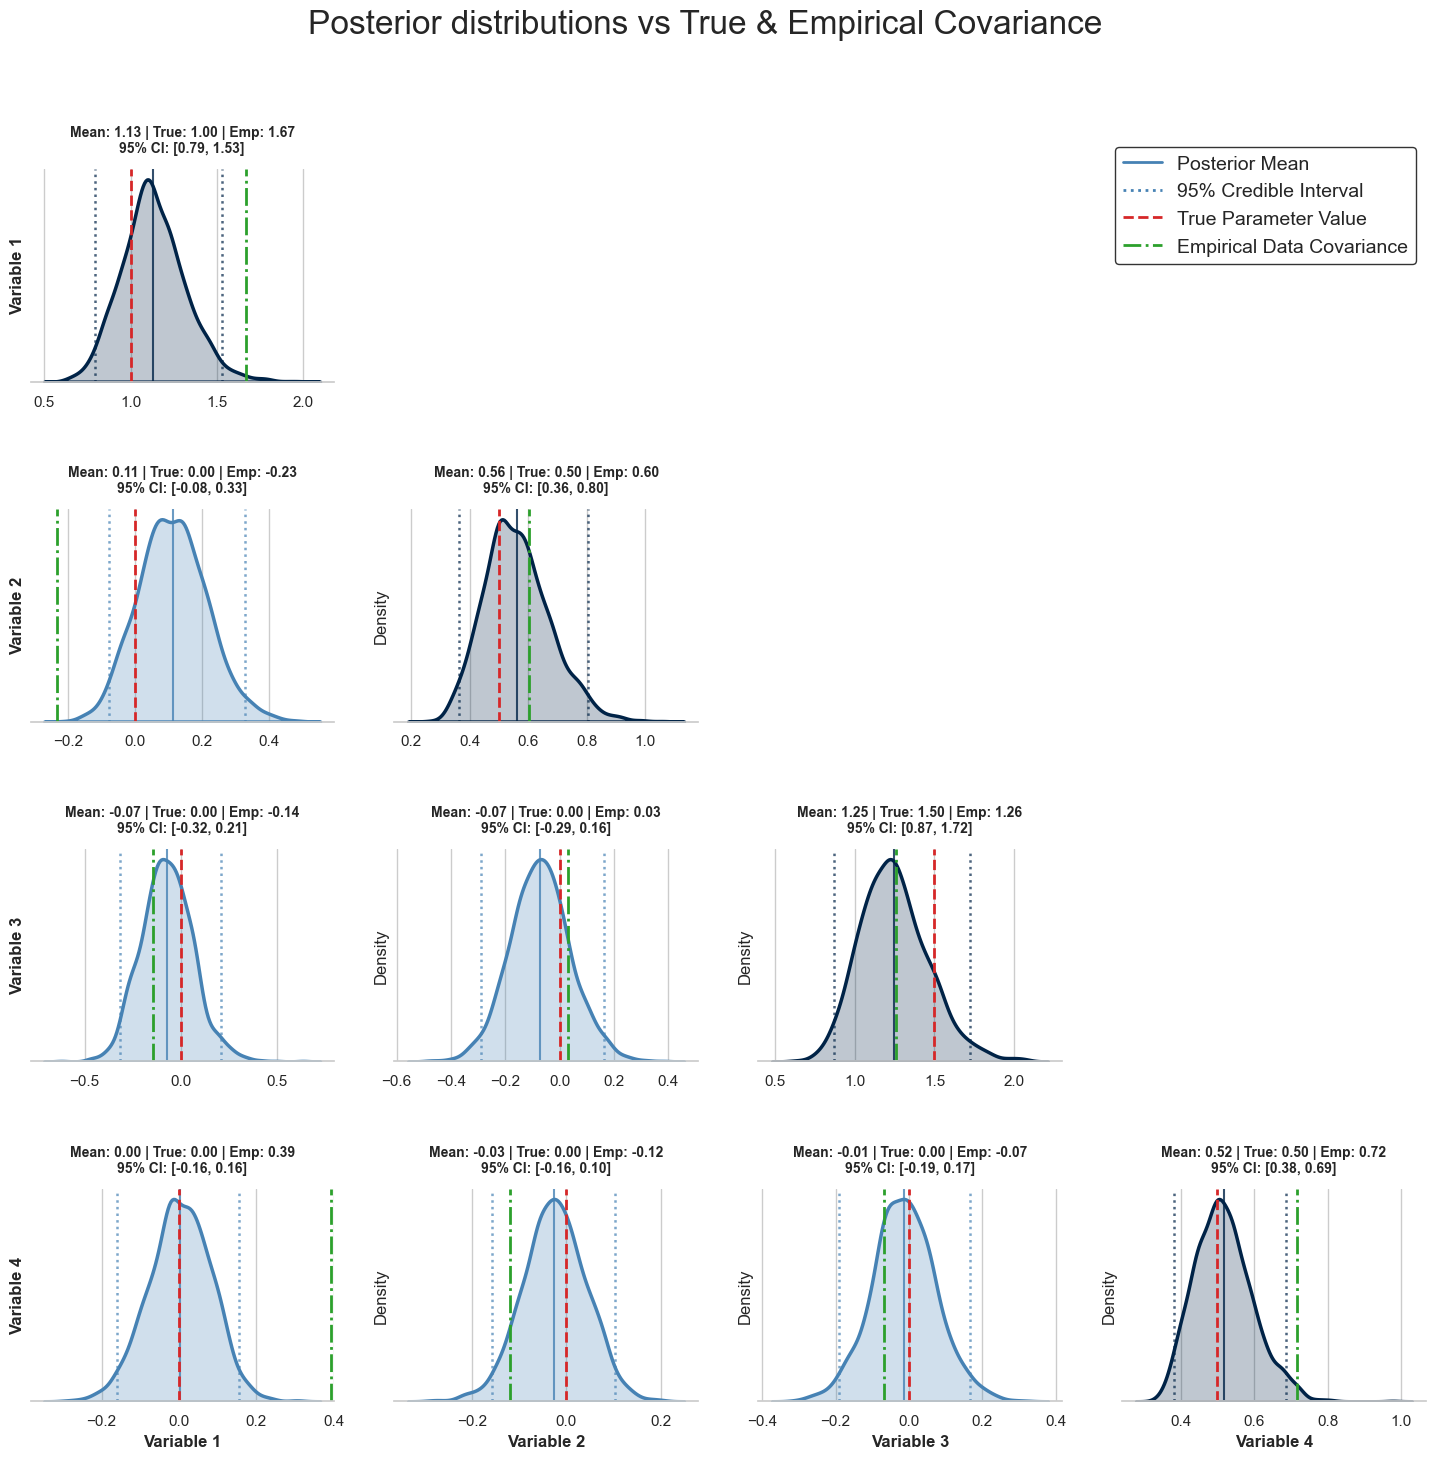


--- Plotting Covariance for Component 1 ---


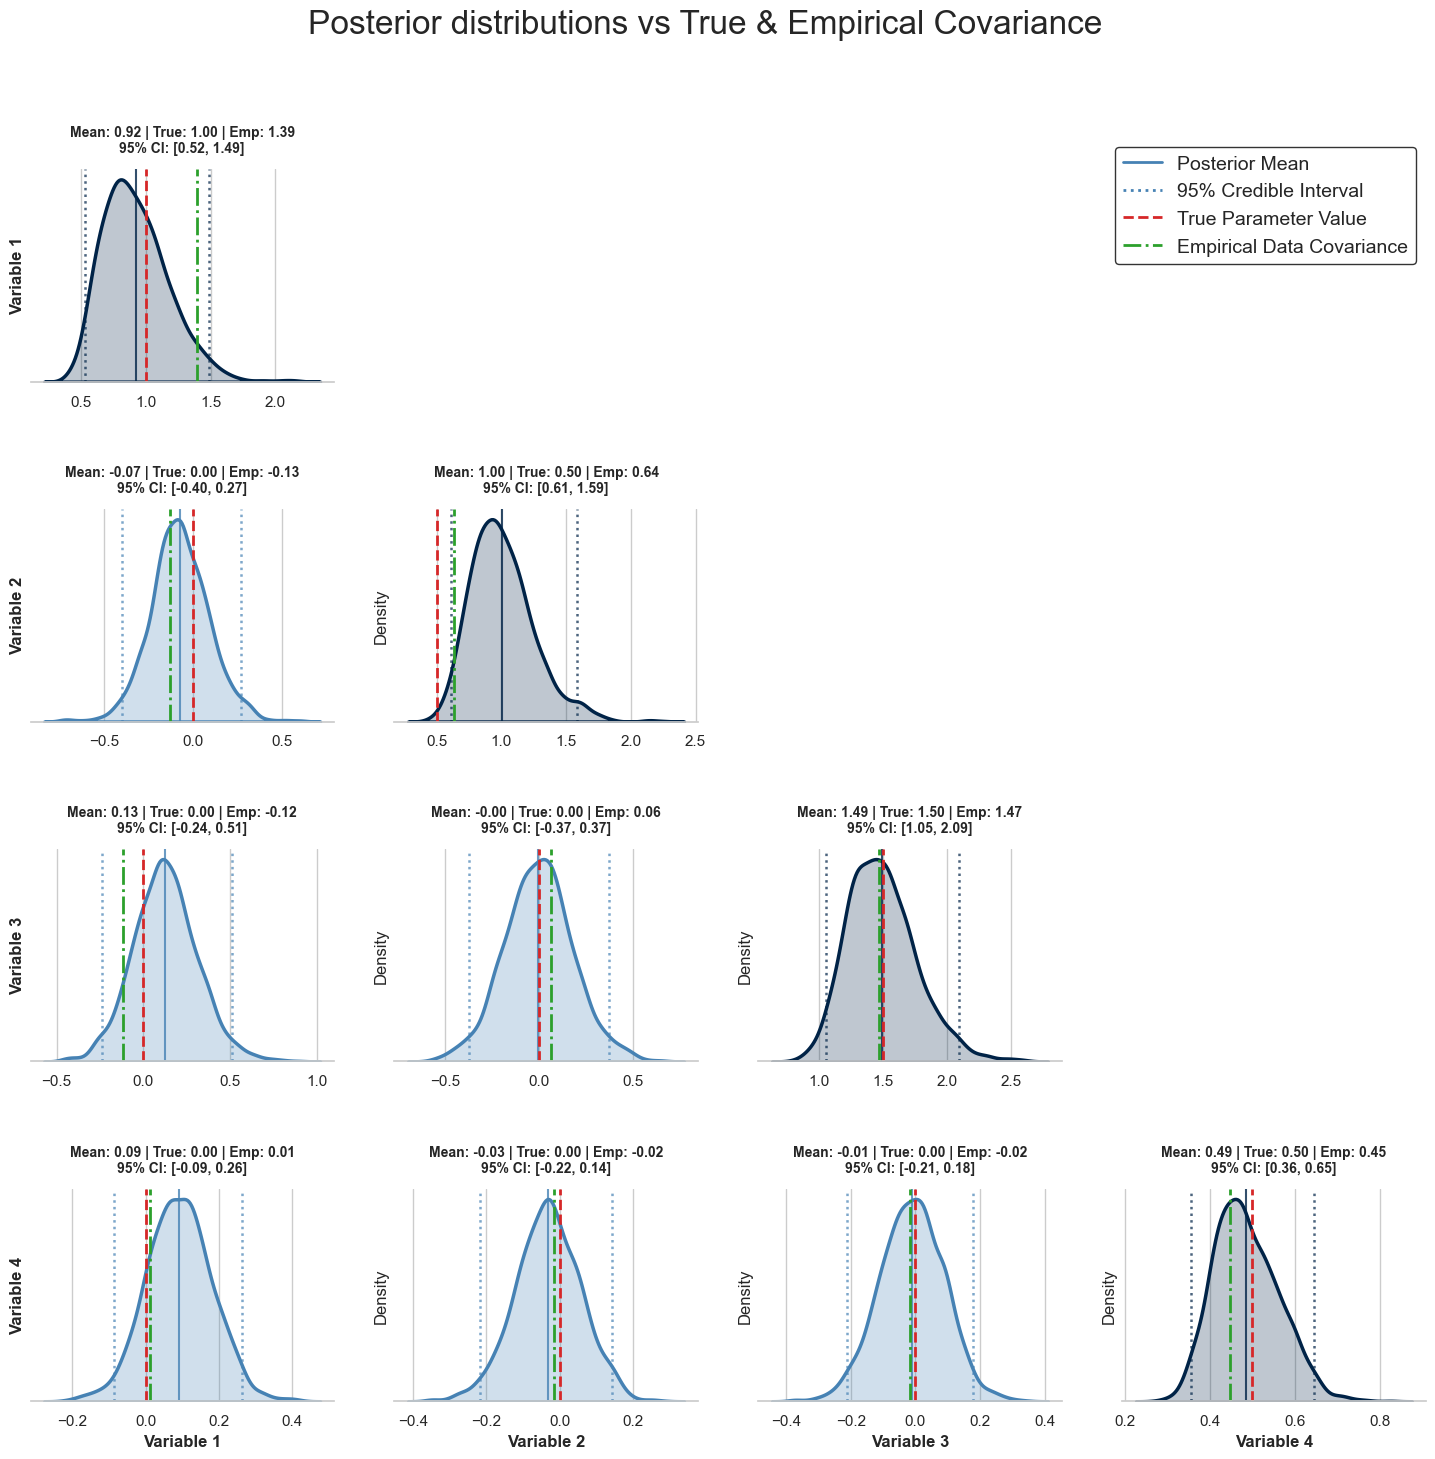


=== Household Heterogeneity (Beta) ===


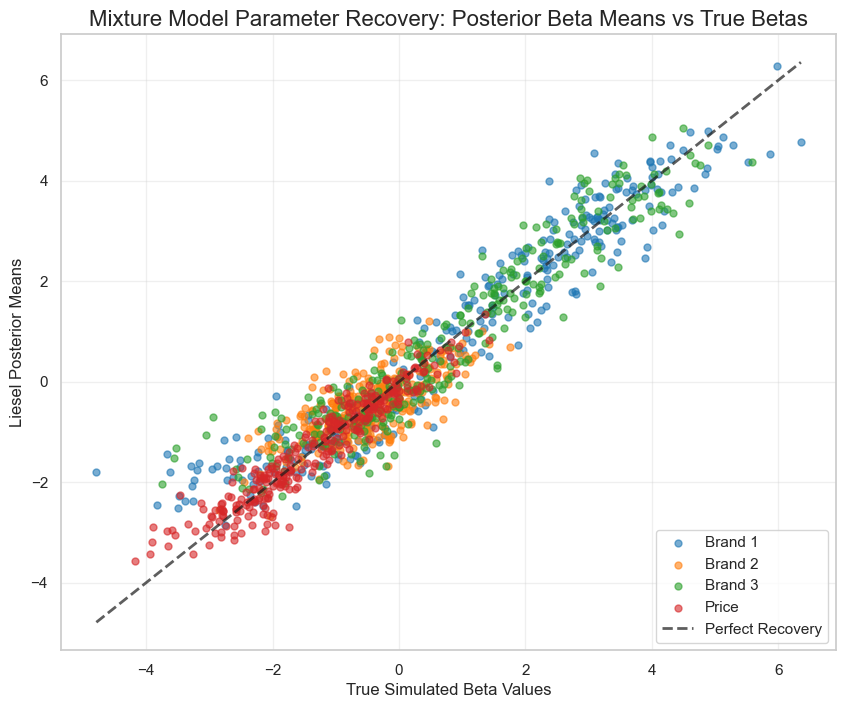

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import jax
import jax.numpy as jnp
from matplotlib.lines import Line2D
import tensorflow_probability.substrates.jax.bijectors as tfb

# Set plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (16, 9)

print("Standardizing array shapes for mixture comparison...")

n_demos = choice_data["n_z"]
n_params = choice_data["n_params"]
n_units = choice_data["n_units"]
K_COMPONENTS = choice_data["TRUE_PI"].shape[0]

param_names = ["Brand 1", "Brand 2", "Brand 3", "Price"]
demo_names  = ["Base (Intercept)", "Demographic 1"]

# ==========================================
# 1. PVEC: MIXING WEIGHTS RECOVERY & TRACE
# ==========================================
print("\n=== Mixing Weights (pvec) Recovery & Traces ===")

# Grab the latent Dirichlet samples you actually generated
pvec_latent_samples = posterior_samples["pvec_latent"] 
b_softmax = tfb.SoftmaxCentered()

# Vectorize the inverse transformation across chains and draws
v_softmax_forward = jax.vmap(jax.vmap(b_softmax.forward))
pvec_samples_full = v_softmax_forward(pvec_latent_samples) # Shape: (chains, draws, K)

# Flatten for analysis
pvec_samples_flat = pvec_samples_full.reshape(-1, K_COMPONENTS)

pvec_df = pd.DataFrame({
    'Component': [f"K={k}" for k in range(K_COMPONENTS)],
    'True_Prob': choice_data["TRUE_PI"],
    'Posterior_Mean': np.mean(pvec_samples_flat, axis=0),
    'Std_Dev': np.std(pvec_samples_flat, axis=0)
}).set_index('Component')
display(pvec_df)

# --- PVEC Trace Plots ---
fig, axes = plt.subplots(1, K_COMPONENTS, figsize=(15, 5), sharey=True)
if K_COMPONENTS == 1: axes = [axes]

n_chains = pvec_samples_full.shape[0]
for k in range(K_COMPONENTS):
    for chain in range(n_chains):
        axes[k].plot(pvec_samples_full[chain, :, k], label=f"Chain {chain}", alpha=0.7)
    axes[k].set_title(f"Component K={k} Probability")
    axes[k].set_xlabel("Iteration")
    if k == 0: axes[k].set_ylabel("Probability")
    axes[k].set_ylim(-0.05, 1.05)
    axes[k].grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, -0.05))
plt.suptitle("MCMC Trace: Mixing Weights (pvec)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# ==========================================
# 2. DELTA: GLOBAL PARAMETERS RECOVERY
# ==========================================
print("\n=== Global Parameters (Delta) ===")
# Shape: (chains, draws, K, n_demos, n_params) -> (samples, K, n_demos, n_params)
delta_samples_reshaped = posterior_samples["Delta"].reshape(-1, K_COMPONENTS, n_demos, n_params)
true_delta = choice_data["TRUE_DELTA"] 

def generate_delta_table(delta_draws, p_names, d_names):
    mean, std = np.mean(delta_draws, axis=0), np.std(delta_draws, axis=0)
    df = pd.DataFrame(index=d_names, columns=p_names)
    for i in range(len(d_names)):
        for j in range(len(p_names)):
            df.iloc[i, j] = f"{mean[i, j]: .2f} ({std[i, j]:.2f})"
    return df

def plot_delta_distributions(delta_samples, t_delta, p_names, d_names):
    fig, axes = plt.subplots(n_demos, n_params, figsize=(4*n_params, 3.5*n_demos))
    
    for d in range(n_demos):
        for p in range(n_params):
            ax = axes[d, p] if n_demos > 1 else axes[p]
            samples = delta_samples[:, d, p]
            ci_low, ci_high = np.percentile(samples, [2.5, 97.5])
            
            sns.kdeplot(samples, ax=ax, fill=True, color="#1f77b4", alpha=0.5, label="Posterior Mean")
            ax.axvline(ci_low, color="#1f77b4", linestyle=":", lw=1.5, label="95% CI")
            ax.axvline(ci_high, color="#1f77b4", linestyle=":", lw=1.5)
            ax.axvline(t_delta[d, p], color="#D62728", linestyle="--", lw=2, label="True Value")
            
            if d == 0: ax.set_title(p_names[p], fontweight='bold')
            if p == 0: ax.set_ylabel(d_names[d], fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            if d == 0 and p == 0:
                handles, labels = ax.get_legend_handles_labels()
                unique = [(h, l) for i, (h, l) in enumerate(zip(handles, labels)) if l not in labels[:i]]
                ax.legend(*zip(*unique), loc='upper right')

    plt.suptitle("Posterior Distributions vs True Values: Global Parameters (Delta)", fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

for k in range(K_COMPONENTS):
    print(f"\n--- Delta Parameters: Component {k} ---")
    display(pd.DataFrame(true_delta[k], index=demo_names, columns=param_names))
    display(generate_delta_table(delta_samples_reshaped[:, k, :, :], param_names, demo_names))
    plot_delta_distributions(delta_samples_reshaped[:, k, :, :], true_delta[k], param_names, demo_names)

# ==========================================
# 3. SIGMA: COVARIANCE RECOVERY & TRACES
# ==========================================
print("\n=== Recovering Covariance Matrices (Sigma) & Traces ===")

# --- Sigma Trace Plots ---
def plot_cholesky_traces_mixture(samples_dict, n_params, K, param_name="sigma_inv_chol_latent", figsize=(15, 12)):
    latent_samples_full = samples_dict[param_name] 
    n_chains, n_draws, _, n_latent = latent_samples_full.shape

    for k in range(K):
        latent_samples = latent_samples_full[:, :, k, :]
        fig, axes = plt.subplots(n_params, n_params, figsize=figsize, sharex=True, sharey=False)
        if n_params == 1: axes = np.array([[axes]])
        latent_idx = 0

        for i in range(n_params):
            for j in range(n_params):
                ax = axes[i, j]
                if i >= j and latent_idx < n_latent:
                    for chain in range(n_chains):
                        ax.plot(latent_samples[chain, :, latent_idx], label=f"Chain {chain}", alpha=0.7)
                    ax.set_title(f"Latent L[{i},{j}]", fontsize=10)
                    latent_idx += 1
                else:
                    ax.axis('off')
                ax.grid(True)
                if i == n_params - 1 or (i >= j and i + 1 < n_params and i + 1 < j): 
                    ax.set_xlabel("Iteration")
                if j == 0: ax.set_ylabel("Value")

        handles, labels = axes[0, 0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower center', ncol=n_chains, bbox_to_anchor=(0.5, 0.02))
        plt.suptitle(f"MCMC Trace: {param_name} - COMPONENT {k}", fontsize=20)
        plt.tight_layout(rect=[0, 0.05, 1, 0.95])
        plt.show()

plot_cholesky_traces_mixture(posterior_samples, n_params, K_COMPONENTS)

# --- Sigma Covariance Recovery ---
b_tril = tfb.FillScaleTriL()

def latent_to_sigma(latent_vec):
    L = b_tril.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

v_latent_to_sigma = jax.vmap(jax.vmap(jax.vmap(latent_to_sigma)))
latent_sigma_samples = posterior_samples["sigma_inv_chol_latent"]
sigma_samples_full = v_latent_to_sigma(latent_sigma_samples).reshape(-1, K_COMPONENTS, n_params, n_params)

def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None):
    n_dim = samples.shape[-1]
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    colors = {"diag": "#002347", "off": "#4682B4", "true": "#D62728", "emp": "#2CA02C"}

    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            c_color = colors["diag"] if i == j else colors["off"]
            
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            sns.kdeplot(data_vec, ax=ax, fill=True, color=c_color, alpha=0.25, lw=2.5)
            ax.axvline(post_mean, color=c_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=c_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=c_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            if true_matrix is not None:
                ax.axvline(true_matrix[i, j], color=colors["true"], linestyle="--", lw=2)
                title_parts.append(f"True: {true_matrix[i, j]:.2f}")
            if empirical_matrix is not None:
                ax.axvline(empirical_matrix[i, j], color=colors["emp"], linestyle="-.", lw=2)
                title_parts.append(f"Emp: {empirical_matrix[i, j]:.2f}")

            ax.set_title(f"{' | '.join(title_parts)}\n95% CI: [{ci_low:.2f}, {ci_high:.2f}]", 
                         fontsize=10, pad=12, fontweight='bold')
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1: ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0: ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    legend_elements = [
        Line2D([0], [0], color=colors["off"], linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=colors["off"], linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=colors["true"], linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=colors["emp"],  linestyle='-.', lw=2, label='Empirical Data Covariance')
    ]
    
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.9, 0.9), 
               fontsize=14, frameon=True, edgecolor='black', fancybox=True)
    plt.suptitle("Posterior distributions vs True & Empirical Covariance", fontsize=24, y=0.98)
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

for k in range(K_COMPONENTS):
    print(f"\n--- Plotting Covariance for Component {k} ---")
    true_segment_mask = choice_data["TRUE_COMPONENTS"] == k
    segment_betas = choice_data["TRUE_BETA"][true_segment_mask]
    
    empirical_sigma_k = np.cov(segment_betas, rowvar=False) if len(segment_betas) > 1 else np.zeros((n_params, n_params))
        
    plot_final_covariance_complete(
        samples=sigma_samples_full[:, k, :, :], 
        true_matrix=choice_data["TRUE_SIGMA"][k], 
        empirical_matrix=empirical_sigma_k
    )

# ==========================================
# 4. BETA: HOUSEHOLD HETEROGENEITY 
# ==========================================
print("\n=== Household Heterogeneity (Beta) ===")

# beta_i Shape: (chains, draws, n_units, n_params)
liesel_beta_full = posterior_samples["beta_i"].reshape(-1, n_units, n_params)
true_betas_full = choice_data["TRUE_BETA"]
l_beta_means = np.mean(liesel_beta_full, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, param in enumerate(param_names):
    ax.scatter(true_betas_full[:, i], l_beta_means[:, i], alpha=0.6, s=25, label=param, color=colors[i])

min_val = min(true_betas_full.min(), l_beta_means.min())
max_val = max(true_betas_full.max(), l_beta_means.max())
ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, alpha=0.7, label='Perfect Recovery')

ax.set_title("Mixture Model Parameter Recovery: Posterior Beta Means vs True Betas", fontsize=16)
ax.set_xlabel("True Simulated Beta Values", fontsize=12)
ax.set_ylabel("Liesel Posterior Means", fontsize=12)
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()